# Laboratorio #7 — NLP end-to-end y Embeddings

**CC3092 · Deep Learning y Sistemas Inteligentes** — Universidad del Valle de Guatemala

**Nicolás Concuá** · Guatemala, octubre de 2026

Repositorio: https://github.com/nicoCT04/Lab7-DL

Este notebook construye un pipeline de NLP de punta a punta: **texto crudo → tokens → IDs → vectores → modelo → salida**.
Se entrenan embeddings de palabras propios sobre WikiText-103 (**skip-gram con negative sampling** implementado en
PyTorch y, como referencia, **Word2Vec de gensim**), se comparan con **GloVe preentrenado** (100 d), se verifica la
aritmética vectorial (*king − man + woman ≈ queen*) y, al final, se usan los embeddings para clasificar noticias de
**AG News**.

## 0. Configuración del entorno

**Hardware:** Apple M4 Pro (GPU integrada, backend **MPS** de PyTorch). El código usa CUDA automáticamente si existe.

Variable de entorno opcional `LAB7_QUICK=1`: usa un subconjunto pequeño del corpus (prueba de humo).

In [1]:
# Descomenta para instalar dependencias (p. ej. en Colab):
# !pip install torch gensim datasets nltk scikit-learn scipy pandas matplotlib

In [2]:
import os, re, time, math, json, random, platform, subprocess, warnings
from collections import Counter
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
import gensim
import gensim.downloader as api
from gensim.test.utils import datapath
import nltk
import sys, contextlib

@contextlib.contextmanager
def silenciar_stderr_c():
    """Las rutinas en C de gensim (BLAS) imprimen desde sus hilos el aviso inofensivo
    "Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'" directo al descriptor 2.
    No afecta los resultados; se redirige stderr a /dev/null solo mientras entrena gensim."""
    sys.stderr.flush()
    copia, nulo = os.dup(2), os.open(os.devnull, os.O_WRONLY)
    os.dup2(nulo, 2)
    try:
        yield
    finally:
        os.dup2(copia, 2); os.close(copia); os.close(nulo)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

# Semilla global para reproducibilidad.
SEED = 42
def fijar_semillas(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
fijar_semillas()

# Rutas robustas: funcionan tanto si se corre desde la raíz del lab como desde notebook/.
_EN_NOTEBOOK = os.path.basename(os.getcwd()) == 'notebook'
RAIZ    = '..' if _EN_NOTEBOOK else '.'
DATA    = os.path.join(RAIZ, 'data')        # cachés pesadas (no se versionan)
REPORTS = os.path.join(RAIZ, 'reports')     # figuras y tablas
os.makedirs(DATA, exist_ok=True); os.makedirs(REPORTS, exist_ok=True)

QUICK = os.environ.get('LAB7_QUICK') == '1'

# Dispositivo: CUDA > MPS (Apple Silicon) > CPU.
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

def nombre_hardware():
    if DEVICE.type == 'cuda':
        return torch.cuda.get_device_name(0)
    try:
        chip = subprocess.check_output(['sysctl', '-n', 'machdep.cpu.brand_string']).decode().strip()
    except Exception:
        chip = platform.processor()
    return f'{chip} ({DEVICE.type.upper()})'

HARDWARE = nombre_hardware()
print('torch', torch.__version__, '| gensim', gensim.__version__)
print('dispositivo:', DEVICE, '|', HARDWARE, '| QUICK =', QUICK)

torch 2.14.1 | gensim 4.4.0
dispositivo: mps | Apple M4 Pro (MPS) | QUICK = False


## 1. Datos

- **WikiText-103 (raw):** artículos de Wikipedia, para entrenar los embeddings propios.
- **AG News:** noticias en 4 categorías (World, Sports, Business, Sci/Tech), para la tarea final (sección 6).
- **GloVe `glove-wiki-gigaword-100`:** embeddings preentrenados de referencia (Wikipedia + Gigaword, 6 mil millones de tokens).
- **Benchmarks (incluidos en gensim):** `questions-words.txt` (analogías), `wordsim353.tsv` y `simlex999.txt` (similitud).

In [3]:
corpus = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")
news   = load_dataset("fancyzhx/ag_news")
glove  = api.load("glove-wiki-gigaword-100")

ANALOGIAS = datapath("questions-words.txt")
WORDSIM   = datapath("wordsim353.tsv")
SIMLEX    = datapath("simlex999.txt")

print(corpus)
print(news)
print('GloVe:', len(glove.key_to_index), 'palabras ×', glove.vector_size, 'dimensiones')

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 1801350
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
GloVe: 400000 palabras × 100 dimensiones


## 2. Exploración y preprocesamiento del texto

### 2.1 ¿Cómo viene el texto crudo?

WikiText-103 viene **una línea por párrafo**. Los títulos de artículo tienen la forma ` = Título = ` y las secciones
` = = Sección = = `. Además, la versión *raw* trae marcadores propios del dataset: ` @-@ ` (guion dentro de palabra),
` @,@ ` (separador de miles) y ` @.@ ` (punto decimal). No contiene `<unk>` (eso solo existe en la versión no-raw).

In [4]:
lineas = corpus['train']['text']
for l in lineas[1:6]:
    print(repr(l[:160]))

' = Valkyria Chronicles III = \n'
''
' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III '
' The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the '
' It met with positive sales in Japan , and was praised by both Japanese and western critics . After release , it received downloadable content , along with an e'


In [5]:
# Expresiones regulares para reconocer la estructura del corpus.
RE_TITULO  = re.compile(r'^ = [^=].* = \n$')       # " = Título = "  -> inicio de un artículo
RE_SECCION = re.compile(r'^ (= )+.*(= )+\n$')      # cualquier encabezado (título o sección)

n_lineas      = len(lineas)
n_vacias      = sum(1 for l in lineas if not l.strip())
n_titulos     = sum(1 for l in lineas if RE_TITULO.match(l))
n_encabezados = sum(1 for l in lineas if RE_SECCION.match(l))
n_parrafos    = n_lineas - n_vacias - n_encabezados
n_tokens_raw  = sum(len(l.split()) for l in lineas)  # tokens "oficiales" del dataset (separados por espacio, incluye puntuación)

print(f'Líneas totales        : {n_lineas:,}')
print(f'  vacías              : {n_vacias:,}')
print(f'  encabezados         : {n_encabezados:,}  (de ellos, títulos de artículo: {n_titulos:,})')
print(f'  párrafos de texto   : {n_parrafos:,}')
print(f'Artículos (títulos)   : {n_titulos:,}')
print(f'Tokens crudos (split) : {n_tokens_raw:,}')

Líneas totales        : 1,801,350
  vacías              : 636,321
  encabezados         : 305,074  (de ellos, títulos de artículo: 29,444)
  párrafos de texto   : 859,955
Artículos (títulos)   : 29,444
Tokens crudos (split) : 101,425,671


> El conteo de títulos (≈29.4 k) es un poco mayor que los 28,475 artículos oficiales de WikiText-103 porque algunos
> artículos contienen líneas con el mismo formato ` = X = `; para este lab se usa el título como frontera de artículo.

### 2.2 Normalización (y por qué)

Decisiones, pensadas para ser **consistentes con el vocabulario de GloVe 6B** (que es *uncased* y fue tokenizado con
el tokenizador de Stanford, estilo Penn Treebank):

| Decisión | Qué se hace | Justificación |
|---|---|---|
| Marcadores `@-@`, `@,@`, `@.@` | se reconstruyen (`role @-@ playing` → `role-playing`, `1 @,@ 000` → `1,000`) | son artefactos del dataset, no texto real |
| Minúsculas | todo a minúsculas | GloVe 6B es *uncased*: si no, `King` y `king` no existirían en GloVe y la comparación sería injusta |
| Puntuación | se elimina | no aporta a analogías/similitud y ocupa ~15 % de los tokens (desperdicia ventanas de contexto) |
| Números | se conservan como dígitos (`1990`, `3.5`, `1,000`) | GloVe también los guarda como dígitos; los años son contexto útil |
| Guiones | se separan (`role-playing` → `role`, `playing`) | aumenta la frecuencia de las palabras base; GloVe contiene ambas formas |
| Contracciones | estilo PTB: `don't` → `do n't`, `king's` → `king 's` (WikiText trae `don 't`, se corrige a `do n't`) | es exactamente como las tokenizó GloVe (`n't` y `'s` son palabras en su vocabulario) |
| Caracteres no ASCII | se conservan las letras Unicode (`é`, `ñ`) | GloVe también las contiene |
| Tokens especiales | `<unk>` para palabras fuera del vocabulario y `<pad>` (índice 0) para relleno | solo se usan en la clasificación (sección 6); en skip-gram las palabras raras simplemente se descartan, como hace Word2Vec |

Lo que **debe ser consistente con GloVe** para que la comparación sea justa: minúsculas, el manejo de números y la
separación de contracciones. Si, por ejemplo, conserváramos mayúsculas, muchas palabras de las analogías no
coincidirían con GloVe y la cobertura sería distinta entre modelos.

In [6]:
RE_MARCAS = re.compile(r' @([-,.])@ ')                     # " @-@ " -> "-"
RE_NT     = re.compile(r"(\w)n't\b")                        # "don't" -> "do n't"
RE_NT_WT  = re.compile(r"(\w)n 't\b")                       # WikiText escribe "don 't" -> "do n't"
RE_CLIT   = re.compile(r"(\w)'(s|re|ve|ll|d|m)\b")          # "king's" -> "king 's"
RE_TOKEN  = re.compile(r"n't|'(?:s|re|ve|ll|d|m)\b"         # clíticos
                       r"|[^\W\d_]+"                         # palabras (letras Unicode)
                       r"|\d+(?:[.,]\d+)*")                  # números: 1990, 3.5, 1,000

def normalizar(texto):
    """Texto crudo -> texto normalizado (marcas de WikiText, minúsculas, contracciones separadas)."""
    t = RE_MARCAS.sub(r'\1', texto).lower()
    t = RE_NT_WT.sub(r"\1 n't", t)
    t = RE_NT.sub(r"\1 n't", t)
    t = RE_CLIT.sub(r"\1 '\2", t)
    return t

def tokenizar(texto):
    """Tokenizador propio por palabra: normaliza y extrae palabras, números y clíticos.
    Todo lo que no coincide con RE_TOKEN (puntuación, guiones, símbolos) se descarta."""
    return RE_TOKEN.findall(normalizar(texto))

print(tokenizar(lineas[3])[:40])

['senjō', 'no', 'valkyria', '3', 'unrecorded', 'chronicles', 'japanese', '戦場のヴァルキュリア', '3', 'lit', 'valkyria', 'of', 'the', 'battlefield', '3', 'commonly', 'referred', 'to', 'as', 'valkyria', 'chronicles', 'iii', 'outside', 'japan', 'is', 'a', 'tactical', 'role', 'playing', 'video', 'game', 'developed', 'by', 'sega', 'and', 'media', 'vision', 'for', 'the', 'playstation']


### 2.3 Tokenizador propio vs. NLTK

Se compara con `nltk.word_tokenize` (Treebank mejorado) en 12 oraciones con casos difíciles. Para comparar solo la
**segmentación**, a la salida de NLTK se le aplican las mismas minúsculas.

In [7]:
nltk.download('punkt', quiet=True); nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

oraciones = [
    "I don't think it's ready yet.",
    "She can't attend the meeting, but they'll call later.",
    "The U.S. economy grew 3.5% in 2019.",
    "Dr. Smith arrived at 5 p.m. on Jan. 3rd.",
    "It's a state-of-the-art, well-known system.",
    "The company's revenue was $1,000,000 last year.",
    "\"Hello!\" he said -- then left...",
    "We'd've gone if you'd asked.",
    "E-mail me at john.doe@example.com or visit www.uvg.edu.gt",
    "The Beatles' songs (1962-1970) remain popular.",
    "New York-based firms hired 1,200 workers.",
    "Pokémon is a café's favorite game, isn't it?",
]

filas = []
for o in oraciones:
    propio = tokenizar(o)
    ref = [t.lower() for t in word_tokenize(o)]
    filas.append({'oración': o, 'propio': ' | '.join(propio), 'nltk': ' | '.join(ref),
                  'iguales': propio == ref})
df_tok = pd.DataFrame(filas)
with pd.option_context('display.max_colwidth', 80):
    display(df_tok[['oración', 'propio', 'nltk']])
df_tok.to_csv(os.path.join(REPORTS, 'tokenizadores.csv'), index=False)

,oración,propio,nltk
0,I don't think it's ready yet.,i | do | n't | think | it | 's | ready | yet,i | do | n't | think | it | 's | ready | yet | .
1,"She can't attend the meeting, but they'll call later.",she | ca | n't | attend | the | meeting | but | they | 'll | call | later,"she | ca | n't | attend | the | meeting | , | but | they | 'll | call | late..."
2,The U.S. economy grew 3.5% in 2019.,the | u | s | economy | grew | 3.5 | in | 2019,the | u.s. | economy | grew | 3.5 | % | in | 2019 | .
3,Dr. Smith arrived at 5 p.m. on Jan. 3rd.,dr | smith | arrived | at | 5 | p | m | on | jan | 3 | rd,dr. | smith | arrived | at | 5 | p.m. | on | jan. | 3rd | .
4,"It's a state-of-the-art, well-known system.",it | 's | a | state | of | the | art | well | known | system,"it | 's | a | state-of-the-art | , | well-known | system | ."
5,"The company's revenue was $1,000,000 last year.","the | company | 's | revenue | was | 1,000,000 | last | year","the | company | 's | revenue | was | $ | 1,000,000 | last | year | ."
6,"""Hello!"" he said -- then left...",hello | he | said | then | left,`` | hello | ! | '' | he | said | -- | then | left | ...
7,We'd've gone if you'd asked.,we | 'd | 've | gone | if | you | 'd | asked,we'd | 've | gone | if | you | 'd | asked | .
8,E-mail me at john.doe@example.com or visit www.uvg.edu.gt,e | mail | me | at | john | doe | example | com | or | visit | www | uvg | e...,e-mail | me | at | john.doe | @ | example.com | or | visit | www.uvg.edu.gt
9,The Beatles' songs (1962-1970) remain popular.,the | beatles | songs | 1962 | 1970 | remain | popular,the | beatles | ' | songs | ( | 1962-1970 | ) | remain | popular | .


In [8]:
# Diferencias token a token (lo que tiene uno y no el otro).
for o in oraciones:
    a, b = Counter(tokenizar(o)), Counter(t.lower() for t in word_tokenize(o))
    solo_p, solo_n = list((a - b).elements()), list((b - a).elements())
    print(f'{o[:45]:45s} | solo propio: {solo_p} | solo NLTK: {solo_n}')

I don't think it's ready yet.                 | solo propio: [] | solo NLTK: ['.']
She can't attend the meeting, but they'll cal | solo propio: [] | solo NLTK: [',', '.']
The U.S. economy grew 3.5% in 2019.           | solo propio: ['u', 's'] | solo NLTK: ['u.s.', '%', '.']
Dr. Smith arrived at 5 p.m. on Jan. 3rd.      | solo propio: ['dr', 'p', 'm', 'jan', '3', 'rd'] | solo NLTK: ['dr.', 'p.m.', 'jan.', '3rd', '.']
It's a state-of-the-art, well-known system.   | solo propio: ['state', 'of', 'the', 'art', 'well', 'known'] | solo NLTK: ['state-of-the-art', ',', 'well-known', '.']
The company's revenue was $1,000,000 last yea | solo propio: [] | solo NLTK: ['$', '.']
"Hello!" he said -- then left...              | solo propio: [] | solo NLTK: ['``', '!', "''", '--', '...']
We'd've gone if you'd asked.                  | solo propio: ['we', "'d"] | solo NLTK: ["we'd", '.']
E-mail me at john.doe@example.com or visit ww | solo propio: ['e', 'mail', 'john', 'doe', 'example', 'com', 'www', 'u

**Dónde difieren:**

- **Contracciones:** ambos las separan igual (`do n't`, `it 's`, `ca n't`, `they 'll`) — se diseñó así a propósito para
  imitar el estilo PTB de GloVe. Diferencia: `we'd've` → NLTK deja `'ve` pegado de otra forma.
- **Guiones:** NLTK conserva `state-of-the-art` y `well-known` como un token; el propio los separa en palabras.
- **Abreviaturas:** NLTK reconoce `U.S.`, `Dr.`, `p.m.`, `Jan.` como un solo token; el propio las rompe (`u`, `s`) o
  quita el punto (`dr`). Esto es lo que más pierde el tokenizador por regex.
- **Puntuación y símbolos:** NLTK emite `,` `.` `$` `%` `"` `(` como tokens; el propio los descarta.
- **Correos/URLs:** NLTK los parte por `@`; el propio los parte en todas las piezas alfanuméricas.

Conclusión: el tokenizador propio es más simple y agresivo (sin puntuación), lo cual es adecuado para entrenar
embeddings de palabras; NLTK es más fiel lingüísticamente (abreviaturas), pero emite muchos tokens de puntuación.

### 2.4 Tokenización del corpus completo y ley de Zipf

Se tokeniza todo el split de entrenamiento agrupando los párrafos por artículo (se omiten líneas vacías y encabezados).

In [9]:
t0 = time.time()
articulos = []      # lista de artículos; cada artículo es una lista de párrafos tokenizados
actual = None
for l in lineas:
    if RE_TITULO.match(l):
        actual = []; articulos.append(actual); continue
    if not l.strip() or RE_SECCION.match(l):
        continue
    tk = tokenizar(l)
    if tk and actual is not None:
        actual.append(tk)

conteo_total = Counter(w for art in articulos for p in art for w in p)
N_TOTAL = sum(conteo_total.values())
print(f'Artículos con texto : {sum(1 for a in articulos if a):,}')
print(f'Párrafos            : {sum(len(a) for a in articulos):,}')
print(f'Tokens normalizados : {N_TOTAL:,}  (vs {n_tokens_raw:,} crudos: la diferencia es la puntuación)')
print(f'Tipos (palabras distintas): {len(conteo_total):,}')
print(f'Tiempo: {time.time() - t0:.1f} s')

Artículos con texto : 29,444
Párrafos            : 859,830
Tokens normalizados : 85,806,132  (vs 101,425,671 crudos: la diferencia es la puntuación)
Tipos (palabras distintas): 554,829
Tiempo: 45.9 s


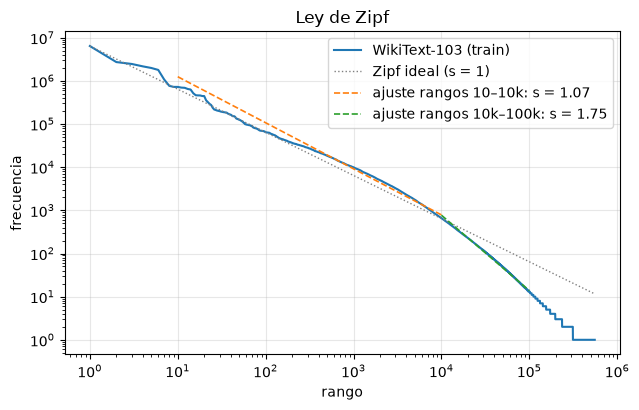

Top     10 palabras cubren  24.3 % de los tokens
Top  1,000 palabras cubren  64.6 % de los tokens
Top 30,000 palabras cubren  95.4 % de los tokens
10 más frecuentes: ['the', 'of', 'and', 'in', 'to', 'a', 'was', 'on', "'s", 'as']


In [10]:
frecs = np.array(sorted(conteo_total.values(), reverse=True), dtype=np.float64)
rangos = np.arange(1, len(frecs) + 1)

# Ajustes lineales en log-log para estimar el exponente s de Zipf, f(r) ∝ r^(-s), en dos tramos:
# cuerpo (rangos 10..10k) y cola (rangos 10k..100k).
def ajuste(r0, r1):
    sel = (rangos >= r0) & (rangos <= r1)
    m, b = np.polyfit(np.log10(rangos[sel]), np.log10(frecs[sel]), 1)
    return -m, b
s_cuerpo, b_cuerpo = ajuste(10, 10_000)
s_cola, b_cola = ajuste(10_000, 100_000)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.loglog(rangos, frecs, lw=1.5, label='WikiText-103 (train)')
ax.loglog(rangos, frecs[0] / rangos, ':', lw=1, color='gray', label='Zipf ideal (s = 1)')
r = np.array([10, 10_000]); ax.loglog(r, 10**b_cuerpo * r**(-s_cuerpo), '--', lw=1.2, label=f'ajuste rangos 10–10k: s = {s_cuerpo:.2f}')
r = np.array([10_000, 100_000]); ax.loglog(r, 10**b_cola * r**(-s_cola), '--', lw=1.2, label=f'ajuste rangos 10k–100k: s = {s_cola:.2f}')
ax.set_xlabel('rango'); ax.set_ylabel('frecuencia'); ax.set_title('Ley de Zipf')
ax.legend(); ax.grid(True, which='major', alpha=0.3)
fig.tight_layout(); fig.savefig(os.path.join(REPORTS, 'zipf.png'), dpi=150); plt.show()

cobertura = {k: frecs[:k].sum() / N_TOTAL * 100 for k in (10, 1_000, 30_000)}
for k, v in cobertura.items():
    print(f'Top {k:>6,} palabras cubren {v:5.1f} % de los tokens')
print('10 más frecuentes:', [w for w, _ in conteo_total.most_common(10)])

**¿Se cumple Zipf?** Sí, en buena medida: hasta el rango ~10 k la curva es casi una recta con pendiente ≈ −1
(frecuencia ∝ 1/rango), justo lo que dice Zipf. En la cola (rangos > 10 k) la pendiente se vuelve más empinada (s ≈ 1.75:
las palabras raras son aún más raras de lo que predice Zipf) y aparecen escalones (miles de palabras con frecuencia 1–2).
Consecuencia práctica: **unas pocas palabras dominan el corpus** (las 10 primeras, casi todas *stopwords*, ya son ~¼ de los
tokens) y con 30 k palabras se cubre el 95 % del texto. Por eso tiene sentido (1) un umbral `min_count` y (2) el
submuestreo de palabras frecuentes.

### 2.5 Subconjunto de entrenamiento

Por cómputo se usa un **subconjunto de ~25 M tokens** (el mínimo pedido es 20 M). Se toman artículos completos en orden
aleatorio (semilla fija) hasta llegar a 25 M; así el subconjunto es representativo de todo Wikipedia y no solo de los
primeros artículos. Los subconjuntos del 25 % y 50 % (sección 4) son **prefijos** de este mismo orden, así que están
anidados. Ambos modelos entrenados (SGNS propio y gensim) usan exactamente estas oraciones.

In [11]:
OBJETIVO_TOKENS = 2_000_000 if QUICK else 25_000_000

orden = list(range(len(articulos)))
random.Random(SEED).shuffle(orden)
oraciones_train, n_acum = [], 0
for i in orden:
    for p in articulos[i]:
        oraciones_train.append(p); n_acum += len(p)
    if n_acum >= OBJETIVO_TOKENS:
        break
conteo = Counter(w for p in oraciones_train for w in p)
N_SUB = sum(conteo.values())
print(f'Subconjunto: {len(oraciones_train):,} párrafos, {N_SUB:,} tokens, {len(conteo):,} tipos')

# Validación de WikiText-103 (texto no visto) para medir tokens desconocidos.
tokens_val = [w for l in corpus['validation']['text'] if l.strip() and not RE_SECCION.match(l) for w in tokenizar(l)]
print(f'Validación WikiText: {len(tokens_val):,} tokens')

Subconjunto: 249,147 párrafos, 25,004,742 tokens, 281,029 tipos
Validación WikiText: 182,245 tokens


### 2.6 Vocabulario y `min_count`

El vocabulario contiene solo las palabras con frecuencia ≥ `min_count` en el subconjunto. Se mide el porcentaje de tokens
desconocidos (que caerían en `<unk>`) tanto en el propio subconjunto como en la validación de WikiText (texto nuevo).

In [12]:
filas = []
for mc in (1, 3, 5, 10, 50, 100):
    vocab_mc = {w for w, c in conteo.items() if c >= mc}
    unk_train = sum(c for w, c in conteo.items() if c < mc) / N_SUB * 100
    unk_val = sum(1 for w in tokens_val if w not in vocab_mc) / len(tokens_val) * 100
    filas.append({'min_count': mc, 'vocabulario': len(vocab_mc),
                  '% <unk> subconjunto': round(unk_train, 2), '% <unk> validación': round(unk_val, 2)})
df_vocab = pd.DataFrame(filas)
display(df_vocab)
df_vocab.to_csv(os.path.join(REPORTS, 'vocab_min_count.csv'), index=False)

,min_count,vocabulario,% <unk> subconjunto,% <unk> validación
0,1,281029,0.00,0.99
1,3,122565,0.79,1.59
2,5,90273,1.23,1.87
3,10,61343,1.98,2.48
4,50,24379,5.21,5.37
5,100,15747,7.63,7.63


**Lectura:** subir `min_count` reduce el vocabulario muchísimo (la mayoría de los tipos son palabras raras, cola de Zipf)
pero el porcentaje de `<unk>` sube muy poco. Con `min_count = 5` el vocabulario se reduce ~3× respecto a usar todo (281 k → 90 k) y
solo ~1–2 % de los tokens quedan fuera. Además, una palabra que aparece 1–4 veces no tiene suficientes contextos para
aprender un vector útil. Se elige **`min_count = 5`** (igual que el default de gensim).

In [13]:
MIN_COUNT = 5
# Vocabulario ordenado por frecuencia (desempate alfabético): el índice 0 es la palabra más frecuente.
itos = [w for w, c in sorted(conteo.items(), key=lambda x: (-x[1], x[0])) if c >= MIN_COUNT]
stoi = {w: i for i, w in enumerate(itos)}
V = len(itos)
frec_vocab = np.array([conteo[w] for w in itos], dtype=np.float64)

# Texto crudo -> tokens -> IDs (las palabras fuera del vocabulario se descartan, como en Word2Vec).
ids_lista, oid_lista = [], []
for k, p in enumerate(oraciones_train):
    x = [stoi[w] for w in p if w in stoi]
    ids_lista.extend(x); oid_lista.extend([k] * len(x))
IDS = np.array(ids_lista, dtype=np.int32)     # corpus como secuencia de IDs
OID = np.array(oid_lista, dtype=np.int32)     # a qué párrafo pertenece cada token (las ventanas no cruzan párrafos)
del ids_lista, oid_lista

print(f'Vocabulario: {V:,} palabras | tokens en el vocabulario: {len(IDS):,} ({len(IDS) / N_SUB * 100:.1f} %)')
ejemplo = "The king's army didn't reach Paris in 1066."
print('texto  :', ejemplo)
print('tokens :', tokenizar(ejemplo))
print('IDs    :', [stoi.get(w, '<unk>') for w in tokenizar(ejemplo)])

# Cobertura en GloVe: qué tan compatible es nuestra normalización con su vocabulario.
en_glove = sum(conteo[w] for w in itos if w in glove.key_to_index) / frec_vocab.sum() * 100
print(f'{sum(w in glove.key_to_index for w in itos):,} de {V:,} palabras del vocabulario existen en GloVe '
      f'({en_glove:.1f} % de los tokens)')

Vocabulario: 90,273 palabras | tokens en el vocabulario: 24,698,313 (98.8 %)
texto  : The king's army didn't reach Paris in 1066.
tokens : ['the', 'king', "'s", 'army', 'did', "n't", 'reach', 'paris', 'in', '1066']
IDs    : [0, 207, 8, 222, 115, 254, 1122, 1518, 3, 18745]
83,928 de 90,273 palabras del vocabulario existen en GloVe (99.7 % de los tokens)


### 2.7 Submuestreo (*subsampling*) de palabras frecuentes

Word2Vec descarta aleatoriamente apariciones de palabras muy frecuentes. Con $f(w)$ = frecuencia relativa y umbral $t$,
la probabilidad de **conservar** una aparición (fórmula del código C de Word2Vec, la misma que usa gensim) es:

$$P_{keep}(w) = \min\left(1,\ \left(\sqrt{\tfrac{f(w)}{t}} + 1\right)\tfrac{t}{f(w)}\right)$$

(El paper original usa $P_{descartar} = 1 - \sqrt{t/f(w)}$; es casi la misma curva.) Se recalcula en **cada epoch**, así
que cada epoch ve una muestra distinta.

In [14]:
f_rel = frec_vocab / frec_vocab.sum()

def prob_conservar(t):
    return np.minimum(1.0, (np.sqrt(f_rel / t) + 1) * t / f_rel)

filas = []
for t in (1e-3, 1e-4, 1e-5):
    pk = prob_conservar(t)
    fila = {'t': t}
    for w in ('the', 'of', 'and'):
        fila[f'% descartado "{w}"'] = round((1 - pk[stoi[w]]) * 100, 1)
    fila['% tokens conservados (total)'] = round((pk * frec_vocab).sum() / frec_vocab.sum() * 100, 1)
    filas.append(fila)
df_sub = pd.DataFrame(filas)
display(df_sub)
df_sub.to_csv(os.path.join(REPORTS, 'subsampling.csv'), index=False)

,t,"% descartado ""the""","% descartado ""of""","% descartado ""and""",% tokens conservados (total)
0,0.00100,87.2,79.2,78.0,77.8
1,0.00010,96.2,94.1,93.8,60.1
2,0.00001,98.8,98.2,98.1,35.2


**¿Por qué ayuda?**

1. **Menos información redundante:** ver `the` junto a `france` no enseña nada sobre `france`; ver `paris` sí. Las
   stopwords aparecen en casi todas las ventanas y dominarían la pérdida.
2. **Velocidad:** con $t=10^{-4}$ se elimina ~40 % de los tokens (y ~94–96 % de `the`, `of`, `and`).
3. **Ventanas efectivamente más amplias:** al quitar stopwords, las palabras de contenido quedan más cerca entre sí,
   así que la misma ventana captura más contexto útil.
4. Mejora la calidad de los vectores de palabras raras (Mikolov et al., 2013).

Se usará **$t = 10^{-4}$** como valor principal (se explora en la sección 4).

### 2.8 Pares (palabra central, contexto) para skip-gram

Para cada palabra central $w_t$ se generan pares $(w_t, w_{t+j})$ con $-W \le j \le W,\ j \ne 0$, sin cruzar párrafos.
Word2Vec usa una **ventana dinámica**: para cada palabra central muestrea $b \sim U\{1..W\}$ y usa solo $|j| \le b$
(así los vecinos cercanos pesan más). Esta función, totalmente vectorizada con NumPy, es la que usará el entrenamiento.

In [15]:
def generar_pares(ids, oid, W, rng=None):
    """Devuelve arreglos (centro, contexto) de todos los pares skip-gram.
    ids: IDs del corpus; oid: párrafo de cada token; W: ventana máxima.
    Si rng no es None se usa ventana dinámica (b ~ U{1..W} por palabra central)."""
    M = len(ids)
    b = rng.integers(1, W + 1, M) if rng is not None else np.full(M, W)
    C, O = [], []
    for d in range(1, W + 1):
        i = np.arange(M - d)
        mismo = oid[i] == oid[i + d]                  # no cruzar párrafos
        m = mismo & (b[i] >= d)                      # i es el centro, i+d el contexto
        C.append(ids[i[m]]); O.append(ids[i[m] + d])
        m = mismo & (b[i + d] >= d)                  # i+d es el centro, i el contexto
        C.append(ids[i[m] + d]); O.append(ids[i[m]])
    return np.concatenate(C), np.concatenate(O)

# Ejemplo pequeño con un párrafo.
p_ej = tokenizar("The quick brown fox jumps over the lazy dog")
ids_ej = np.array([stoi[w] for w in p_ej], dtype=np.int32)
c_ej, o_ej = generar_pares(ids_ej, np.zeros(len(ids_ej), dtype=np.int32), W=2)
print('pares con W=2 para "fox":', [(itos[c], itos[o]) for c, o in zip(c_ej, o_ej) if itos[c] == 'fox'])

pares con W=2 para "fox": [('fox', 'jumps'), ('fox', 'brown'), ('fox', 'over'), ('fox', 'quick')]


In [16]:
W_PARES = 5
rng = np.random.default_rng(SEED)
filas = []
for nombre, ids_, oid_ in [('sin submuestreo', IDS, OID)] + [
        (f'con submuestreo t={t:g}', IDS[m], OID[m])
        for t in (1e-3, 1e-4, 1e-5)
        for m in [rng.random(len(IDS)) < prob_conservar(t)[IDS]]]:
    c_fijo, _ = generar_pares(ids_, oid_, W_PARES)                  # ventana fija W
    c_din, _ = generar_pares(ids_, oid_, W_PARES, rng)              # ventana dinámica (Word2Vec)
    filas.append({'corpus': nombre, 'tokens': len(ids_),
                  f'pares ventana fija W={W_PARES}': len(c_fijo),
                  'pares ventana dinámica': len(c_din)})
df_pares = pd.DataFrame(filas)
display(df_pares)
df_pares.to_csv(os.path.join(REPORTS, 'pares_skipgram.csv'), index=False)
del c_fijo, c_din

,corpus,tokens,pares ventana fija W=5,pares ventana dinámica
0,sin submuestreo,24698313,239625260,144762556
1,con submuestreo t=0.001,19218822,184841242,111884233
2,con submuestreo t=0.0001,14836903,141045800,85573573
3,con submuestreo t=1e-05,8704065,79868218,48870961


**Lectura:** con ventana fija cada token genera ~$2W = 10$ pares; con ventana dinámica el promedio es $W + 1 = 6$
(porque $E[b] = 3$ a cada lado). El submuestreo con $t=10^{-4}$ reduce los pares por epoch ~40 %: es la
principal razón por la que el entrenamiento se acelera, y lo que se elimina son sobre todo pares con stopwords.

## 3. Investigación: embeddings en PyTorch y gensim

### 3.1 `nn.Embedding` [1]

Es una **tabla de búsqueda** (*lookup table*) de forma `(num_embeddings, embedding_dim)`: recibe IDs enteros y devuelve
la fila correspondiente. Matemáticamente equivale a multiplicar un vector *one-hot* por una matriz de pesos, pero sin
construir el one-hot (mucho más eficiente). Sus filas son parámetros entrenables.

| Parámetro | Propósito |
|---|---|
| `num_embeddings` | tamaño del vocabulario (número de filas) |
| `embedding_dim` | dimensión de cada vector (columnas): 50, 100, 300… |
| `padding_idx` | índice reservado para relleno (`<pad>`): su vector se inicializa en ceros y **no recibe gradiente** |
| `sparse` | si es `True`, el gradiente es una matriz dispersa (solo las filas usadas en el batch). Ahorra memoria con vocabularios grandes; requiere optimizadores compatibles (`SGD`, `SparseAdam`, `Adagrad`) |
| `max_norm` | (opcional) renormaliza los vectores cuya norma supere ese valor |

**`nn.Embedding.from_pretrained(embeddings, freeze=True, padding_idx=None)`** crea la tabla a partir de una matriz ya
entrenada (p. ej. GloVe). Con `freeze=True` (default) los pesos **no se actualizan** (`requires_grad=False`): se usan
como *features* fijas. Con `freeze=False` se hace *fine-tuning* junto con la tarea.

### 3.2 `nn.EmbeddingBag` [1]

Combina en una sola operación (más rápida y con menos memoria) el *lookup* y la **agregación** de varios embeddings,
sin crear el tensor intermedio `(batch, largo, dim)`. Es ideal para modelos tipo "bolsa de palabras" (como el
clasificador de la sección 6).

- `mode='mean'` (default): promedio de los vectores del documento; `'sum'`: suma; `'max'`: máximo por dimensión.
- **`offsets`:** en lugar de un batch rectangular con relleno, se pasa **un solo tensor 1D** con todos los IDs
  concatenados y un tensor `offsets` con la posición donde empieza cada documento. Así no hace falta `<pad>`:
  documentos de longitudes distintas se procesan sin desperdicio.
- `per_sample_weights` (solo con `'sum'`): pondera cada palabra (p. ej. por TF-IDF). `padding_idx` también se ignora en la agregación.

In [17]:
# Demostración pequeña de nn.Embedding y nn.EmbeddingBag con offsets.
torch.manual_seed(SEED)
emb = nn.Embedding(num_embeddings=6, embedding_dim=3, padding_idx=0)
print('nn.Embedding, fila del <pad> (índice 0):', emb.weight[0].tolist())
print('lookup de [[1, 2, 0]] -> forma', tuple(emb(torch.tensor([[1, 2, 0]])).shape))

# Dos "documentos": [1, 2, 4] y [3, 5] concatenados en un solo tensor 1D.
ids_docs = torch.tensor([1, 2, 4, 3, 5])
offsets  = torch.tensor([0, 3])          # doc 0 empieza en la posición 0, doc 1 en la 3
for modo in ('mean', 'sum', 'max'):
    bag = nn.EmbeddingBag.from_pretrained(emb.weight.detach(), mode=modo)
    print(f'EmbeddingBag mode={modo:4s} ->', bag(ids_docs, offsets).detach().numpy().astype(float).round(3).tolist())
# Comprobación: 'mean' es exactamente el promedio de las filas del documento 0.
print('promedio manual doc 0:', emb.weight[[1, 2, 4]].mean(0).detach().numpy().astype(float).round(3).tolist())

nn.Embedding, fila del <pad> (índice 0): [0.0, 0.0, 0.0]
lookup de [[1, 2, 0]] -> forma (1, 3, 3)
EmbeddingBag mode=mean -> [[0.336, 0.321, 0.394], [0.087, 0.15, 0.47]]
EmbeddingBag mode=sum  -> [[1.009, 0.964, 1.183], [0.173, 0.301, 0.939]]
EmbeddingBag mode=max  -> [[0.801, 1.681, 1.078], [0.86, 0.61, 1.335]]
promedio manual doc 0: [0.336, 0.321, 0.394]


### 3.3 Conceptos

**CBOW vs. skip-gram** [2]. Ambos son las dos arquitecturas de Word2Vec (una red de una capa lineal, sin no-linealidad):

| | CBOW (*continuous bag of words*) | Skip-gram |
|---|---|---|
| Tarea | predecir la palabra **central** a partir del **promedio** de sus contextos | predecir cada palabra de **contexto** a partir de la central |
| Ejemplos por ventana | 1 | 2W (un par por contexto) |
| Velocidad | más rápido | más lento |
| Calidad | mejor con palabras frecuentes, suaviza | mejor con **palabras raras** y en analogías semánticas, aun con poco corpus |

**Negative sampling (SGNS)** [3]. El softmax sobre todo el vocabulario es carísimo (90 k clases por par). En su lugar,
cada par real $(w, c)$ se vuelve una clasificación binaria contra $K$ palabras "negativas" $n_i$ muestreadas de la
distribución unigrama elevada a 3/4:

$$\mathcal{L} = -\log\sigma(\mathbf{u}_c^\top \mathbf{v}_w) - \sum_{i=1}^{K}\log\sigma(-\mathbf{u}_{n_i}^\top \mathbf{v}_w), \qquad P_n(w) \propto \text{count}(w)^{0.75}$$

El exponente 0.75 sube un poco la probabilidad de palabras raras frente a la unigrama pura.

**¿Por qué dos matrices, W (entrada) y W' (salida)?** [2][4] Cada palabra tiene un vector $\mathbf{v}_w$ (fila de
**W**, cuando es palabra central) y otro $\mathbf{u}_w$ (fila de **W'**, cuando es contexto). Si se usara una sola, el
modelo tendría que dar un producto punto alto entre una palabra y sí misma ($\mathbf{v}_w^\top\mathbf{v}_w = \|\mathbf{v}_w\|^2$),
aunque una palabra rara vez aparece en su propio contexto; además una palabra y sus vecinos típicos tienen papeles
distintos (un sustantivo y el verbo que lo acompaña no deben ser idénticos). Con dos matrices el problema es más
fácil de optimizar. **Se conserva W** (la de entrada) como embedding final; algunas implementaciones (como GloVe)
usan la suma W + W'.

**Word2Vec (predictivo) vs. GloVe (conteos)** [4][5]:

| | Word2Vec (SGNS) | GloVe |
|---|---|---|
| Tipo | **predictivo**: aprende recorriendo ventanas y prediciendo contextos (SGD local) | **basado en conteos**: primero construye la matriz global de co-ocurrencias $X_{ij}$ |
| Objetivo | clasificar pares reales vs. negativos | mínimos cuadrados ponderados: $\mathbf{w}_i^\top\tilde{\mathbf{w}}_j + b_i + \tilde b_j \approx \log X_{ij}$ |
| Información | local (ventana a ventana) | global (estadísticas de todo el corpus de una vez) |
| Relación | Levy & Goldberg [4]: SGNS factoriza implícitamente la matriz PMI desplazada ($\text{PMI} - \log K$) | factoriza explícitamente log-co-ocurrencias |

En la práctica ambos dan resultados parecidos con los hiperparámetros adecuados; la mayor diferencia suele venir del
**tamaño del corpus**.

**Word2Vec en gensim** [6]: `Word2Vec(sentences, vector_size, window, min_count, sg=1, negative, sample, alpha,
min_alpha, epochs, workers, seed)`. `sg=1` es skip-gram (0 = CBOW), `negative` = K, `sample` = umbral de submuestreo
$t$, `alpha → min_alpha` es el learning rate con decaimiento lineal. Los vectores quedan en `model.wv`
(`KeyedVectors`), que ofrece `most_similar`, `evaluate_word_analogies`, `evaluate_word_pairs` y `save`/`load`.

**Referencias:** [1] PyTorch docs, *torch.nn.Embedding / EmbeddingBag*. [2] Mikolov et al. (2013a), *Efficient
Estimation of Word Representations in Vector Space*. [3] Mikolov et al. (2013b), *Distributed Representations of Words
and Phrases and their Compositionality*. [4] Levy & Goldberg (2014), *Neural Word Embedding as Implicit Matrix
Factorization*. [5] Pennington, Socher & Manning (2014), *GloVe: Global Vectors for Word Representation*. [6] Řehůřek &
Sojka, *gensim* (documentación de `Word2Vec`).

## 4. Construcción y entrenamiento de los embeddings

### 4.1 Funciones de evaluación

Se usan **solo WordSim-353 y las analogías** para seleccionar configuraciones (SimLex-999 se reserva para la sección 6).

- **Analogías** (`questions-words.txt`, 19,544 preguntas «a es a b como c es a d»): se predice $d$ con **3CosAdd**,
  $\arg\max_{x} \cos(x,\ b - a + c)$ sobre vectores normalizados, excluyendo $a, b, c$. Igual que
  `evaluate_word_analogies` de gensim, durante el entrenamiento se restringe la búsqueda a las **30,000 palabras más
  frecuentes** de cada modelo (rápido y estándar). Las 5 primeras categorías son **semánticas** y las 9 `gram*` **sintácticas**.
- **WordSim-353:** correlación de **Spearman** entre la similitud coseno del modelo y la calificación humana.
- **Vecinos más cercanos** de palabras de control: `king, france, computer, good, january, run`.

Las funciones son genéricas (sirven para el SGNS, gensim y GloVe) y corren en GPU.

In [18]:
def cargar_analogias(ruta=ANALOGIAS):
    preguntas = []; seccion = None
    for l in open(ruta):
        if l.startswith(':'):
            seccion = l[1:].strip(); continue
        preguntas.append((seccion, *l.lower().split()))
    return preguntas

PREGUNTAS = cargar_analogias()
SECCIONES = list(dict.fromkeys(p[0] for p in PREGUNTAS))
SEMANTICAS = set(SECCIONES[:5])          # capitales, monedas, ciudades-estado, familia
print(f'{len(PREGUNTAS):,} analogías en {len(SECCIONES)} categorías:', SECCIONES)

def matriz_normalizada(E):
    """Vectores de norma 1 (en GPU) para que el producto punto sea la similitud coseno."""
    E = torch.as_tensor(np.asarray(E) if not torch.is_tensor(E) else E, dtype=torch.float32)
    return F.normalize(E.to(DEVICE), dim=1)

def evaluar_analogias(E, stoi, vocab_eval, metodo='add', preguntas=PREGUNTAS, lote=2048):
    """Resuelve todas las analogías cuyas 4 palabras estén en vocab_eval (lista de palabras candidatas).
    metodo='add' -> 3CosAdd: cos(x, b) - cos(x, a) + cos(x, c)
    metodo='mul' -> 3CosMul: cos'(x, b) * cos'(x, c) / (cos'(x, a) + 0.001), con cos' = (cos + 1) / 2
    Devuelve un DataFrame con una fila por pregunta evaluada (sección, acierto)."""
    pos = {w: j for j, w in enumerate(vocab_eval)}
    validas = [p for p in preguntas if all(w in pos for w in p[1:])]
    En = matriz_normalizada(E)[torch.tensor([stoi[w] for w in vocab_eval], device=DEVICE)]
    a, b, c, d = [torch.tensor([pos[p[i]] for p in validas], device=DEVICE) for i in range(1, 5)]
    aciertos = torch.zeros(len(validas), dtype=torch.bool, device=DEVICE)
    for i in range(0, len(validas), lote):
        s = slice(i, i + lote)
        sa, sb, sc = En[a[s]] @ En.T, En[b[s]] @ En.T, En[c[s]] @ En.T   # similitudes con todo el vocabulario
        if metodo == 'add':
            puntaje = sb - sa + sc
        else:
            puntaje = ((sb + 1) / 2) * ((sc + 1) / 2) / ((sa + 1) / 2 + 1e-3)
        for z in (a, b, c):                                               # excluir las palabras de la consulta
            puntaje.scatter_(1, z[s].unsqueeze(1), -1e9)
        aciertos[s] = puntaje.argmax(1) == d[s]
    return pd.DataFrame({'seccion': [p[0] for p in validas], 'acierto': aciertos.cpu().numpy()})

def resumen_analogias(df, total_preguntas=len(PREGUNTAS)):
    sem = df['seccion'].isin(SEMANTICAS)
    return {'sem': df.loc[sem, 'acierto'].mean() * 100, 'sin': df.loc[~sem, 'acierto'].mean() * 100,
            'total': df['acierto'].mean() * 100, 'cobertura': len(df) / total_preguntas * 100}

def evaluar_similitud(E, stoi, ruta=WORDSIM):
    """Spearman entre coseno del modelo y juicio humano (WordSim-353 o SimLex-999). Omite pares fuera del vocabulario."""
    from scipy.stats import spearmanr
    En = matriz_normalizada(E); humano, modelo, total = [], [], 0
    for l in open(ruta, encoding='utf8'):
        partes = l.strip().split('\t')
        if l.startswith('#') or len(partes) < 3:
            continue
        try:
            puntaje = float(partes[2])
        except ValueError:
            continue                                   # encabezado
        total += 1
        w1, w2 = partes[0].lower(), partes[1].lower()
        if w1 in stoi and w2 in stoi:
            humano.append(puntaje); modelo.append((En[stoi[w1]] @ En[stoi[w2]]).item())
    return spearmanr(humano, modelo).correlation, len(humano) / total * 100

PALABRAS_CONTROL = ['king', 'france', 'computer', 'good', 'january', 'run']

def vecinos(E, stoi, itos, palabra, k=5):
    En = matriz_normalizada(E)
    sims = En @ En[stoi[palabra]]
    sims[stoi[palabra]] = -1
    top = torch.topk(sims, k)
    return [(itos[i], round(s, 3)) for s, i in zip(top.values.tolist(), top.indices.tolist())]

def evaluar_epoch(E, stoi, itos):
    """Todo lo que se registra al final de cada epoch."""
    r = resumen_analogias(evaluar_analogias(E, stoi, itos[:30_000]))
    r['wordsim'], _ = evaluar_similitud(E, stoi, WORDSIM)
    r['vecinos'] = {w: [v for v, _ in vecinos(E, stoi, itos, w)] for w in PALABRAS_CONTROL if w in stoi}
    return r

# Validación de la función propia contra gensim con GloVe (top 30k): deben coincidir.
t0 = time.time()
propio = resumen_analogias(evaluar_analogias(glove.vectors, glove.key_to_index, glove.index_to_key[:30_000]))
total_gensim, _ = glove.evaluate_word_analogies(ANALOGIAS, restrict_vocab=30_000)
print(f'GloVe analogías (top 30k) — función propia: {propio["total"]:.2f} % | gensim: {total_gensim * 100:.2f} % '
      f'({time.time() - t0:.1f} s)')
ws_glove, cov = evaluar_similitud(glove.vectors, glove.key_to_index, WORDSIM)
print(f'GloVe WordSim-353: Spearman = {ws_glove:.3f} (cobertura {cov:.0f} %)')

19,544 analogías en 14 categorías: ['capital-common-countries', 'capital-world', 'currency', 'city-in-state', 'family', 'gram1-adjective-to-adverb', 'gram2-opposite', 'gram3-comparative', 'gram4-superlative', 'gram5-present-participle', 'gram6-nationality-adjective', 'gram7-past-tense', 'gram8-plural', 'gram9-plural-verbs']


GloVe analogías (top 30k) — función propia: 65.49 % | gensim: 65.49 % (4.9 s)
GloVe WordSim-353: Spearman = 0.533 (cobertura 100 %)


### 4.2 Skip-gram con negative sampling (SGNS) desde cero en PyTorch

**Modelo:** dos tablas `nn.Embedding` de tamaño `V × D`:
- `entrada` (**W**): vector $\mathbf{v}_w$ de la palabra central. Inicialización uniforme en $[-0.5/D,\ 0.5/D]$ (como Word2Vec).
- `salida` (**W'**): vector $\mathbf{u}_c$ de la palabra de contexto. Inicialización en **ceros** (como Word2Vec).

Para cada par (centro $w$, contexto $c$) y $K$ negativos $n_i \sim P_n$:
$\ \ \mathcal{L} = -\log\sigma(\mathbf{u}_c^\top\mathbf{v}_w) - \sum_i \log\sigma(-\mathbf{u}_{n_i}^\top\mathbf{v}_w)$.

**Entrenamiento** (réplica de Word2Vec, pero en lotes en GPU):
1. En cada epoch: **submuestreo** nuevo → **pares** con ventana dinámica (`generar_pares` de la sección 2.8) → **barajar**.
2. Lotes de 16,384 pares; los negativos se muestrean de $\text{count}^{0.75}$ con búsqueda binaria sobre la CDF.
3. **SGD** con la pérdida **sumada** del lote (cada par aporta su gradiente completo, como en Word2Vec) y
   learning rate con **decaimiento lineal** de `lr` a `1e-4` a lo largo de todo el entrenamiento (igual que gensim
   `alpha → min_alpha`).

Se registran: pérdida promedio por epoch y cada 500 lotes, analogías (sem/sin/total) y WordSim al final de cada
epoch, vecinos de las palabras de control, tiempo por epoch y memoria pico del dispositivo.

In [19]:
class SkipGramNS(nn.Module):
    def __init__(self, V, D):
        super().__init__()
        self.entrada = nn.Embedding(V, D)    # W  (palabra central)  -> es el embedding que se conserva
        self.salida  = nn.Embedding(V, D)    # W' (palabra de contexto)
        nn.init.uniform_(self.entrada.weight, -0.5 / D, 0.5 / D)
        nn.init.zeros_(self.salida.weight)

    def forward(self, centro, contexto, negativos):
        v  = self.entrada(centro)                         # (B, D)
        u  = self.salida(contexto)                        # (B, D)
        un = self.salida(negativos)                       # (B, K, D)
        pos = F.logsigmoid((v * u).sum(1))                               # log σ(u_c · v_w)
        neg = F.logsigmoid(-torch.bmm(un, v.unsqueeze(2)).squeeze(2))    # log σ(-u_n · v_w)
        return -(pos + neg.sum(1))                        # pérdida por par, forma (B,)

def sincronizar():
    if DEVICE.type == 'cuda': torch.cuda.synchronize()
    elif DEVICE.type == 'mps': torch.mps.synchronize()

def memoria_dispositivo():
    if DEVICE.type == 'cuda': return torch.cuda.max_memory_allocated()
    if DEVICE.type == 'mps': return torch.mps.driver_allocated_memory()
    return 0

def preparar_corpus(fraccion=1.0, min_count=MIN_COUNT):
    """Prefijo del subconjunto (fracción de tokens) -> vocabulario + secuencia de IDs.
    Las fracciones son prefijos del mismo orden aleatorio de artículos, así que están anidadas."""
    if fraccion == 1.0 and min_count == MIN_COUNT:
        return dict(itos=itos, stoi=stoi, frec=frec_vocab, ids=IDS, oid=OID, n_tokens=N_SUB, oraciones=oraciones_train)
    limite, acum, k = fraccion * N_SUB, 0, 0
    while acum < limite:
        acum += len(oraciones_train[k]); k += 1
    ors = oraciones_train[:k]
    cnt = Counter(w for p in ors for w in p)
    it = [w for w, c in sorted(cnt.items(), key=lambda x: (-x[1], x[0])) if c >= min_count]
    st = {w: i for i, w in enumerate(it)}
    ids, oid = [], []
    for j, p in enumerate(ors):
        x = [st[w] for w in p if w in st]; ids.extend(x); oid.extend([j] * len(x))
    return dict(itos=it, stoi=st, frec=np.array([cnt[w] for w in it], dtype=np.float64),
                ids=np.array(ids, dtype=np.int32), oid=np.array(oid, dtype=np.int32), n_tokens=acum, oraciones=ors)

def entrenar_sgns(cfg, verbose=True):
    """Entrena un SGNS con la configuración cfg y devuelve (embeddings de entrada, historial, datos del corpus)."""
    fijar_semillas(SEED)
    rng = np.random.default_rng(SEED)
    datos = preparar_corpus(cfg['fraccion'], cfg['min_count'])
    Vc, frec = len(datos['itos']), datos['frec']
    f = frec / frec.sum()
    p_keep = np.minimum(1.0, (np.sqrt(f / cfg['t']) + 1) * cfg['t'] / f)
    cdf_neg = torch.tensor(np.cumsum(frec ** 0.75 / (frec ** 0.75).sum()), dtype=torch.float32, device=DEVICE)

    modelo = SkipGramNS(Vc, cfg['dim']).to(DEVICE)
    opt = torch.optim.SGD(modelo.parameters(), lr=cfg['lr'])
    B, K, LR_MIN = cfg['batch'], cfg['negativos'], 1e-4
    hist = dict(cfg=cfg, n_tokens=int(datos['n_tokens']), vocab=Vc, epochs=[], perdida_pasos=[])
    total_pares, vistos, mem_pico = None, 0, 0
    t_total = time.time()
    for ep in range(1, cfg['epochs'] + 1):
        t0 = time.time()
        keep = rng.random(len(datos['ids'])) < p_keep[datos['ids']]                  # 1) submuestreo
        c, o = generar_pares(datos['ids'][keep], datos['oid'][keep], cfg['ventana'], rng)   # 2) pares
        perm = rng.permutation(len(c)); c, o = c[perm], o[perm]                       # 3) barajar
        total_pares = total_pares or len(c) * cfg['epochs']
        c_t, o_t = torch.from_numpy(c).to(DEVICE), torch.from_numpy(o).to(DEVICE)
        suma_ep = torch.zeros((), device=DEVICE); suma_tramo = torch.zeros((), device=DEVICE); n_tramo = 0
        for paso, i in enumerate(range(0, len(c), B)):
            lr = cfg['lr'] - (cfg['lr'] - LR_MIN) * min(1.0, vistos / total_pares)   # decaimiento lineal
            for g in opt.param_groups: g['lr'] = lr
            cc, oo = c_t[i:i + B], o_t[i:i + B]
            neg = torch.searchsorted(cdf_neg, torch.rand(len(cc), K, device=DEVICE)).clamp_(max=Vc - 1)
            perdida = modelo(cc, oo, neg)
            opt.zero_grad(set_to_none=True)
            perdida.sum().backward()
            opt.step()
            suma_ep += perdida.detach().sum(); suma_tramo += perdida.detach().sum()
            n_tramo += len(cc); vistos += len(cc)
            if (paso + 1) % 500 == 0:                                                 # pérdida cada 500 lotes
                hist['perdida_pasos'].append((vistos, (suma_tramo / n_tramo).item()))
                suma_tramo.zero_(); n_tramo = 0
                mem_pico = max(mem_pico, memoria_dispositivo())
        sincronizar()
        t_ep = time.time() - t0
        mem_pico = max(mem_pico, memoria_dispositivo())
        ev = evaluar_epoch(modelo.entrada.weight.detach(), datos['stoi'], datos['itos'])
        ev.update(epoch=ep, perdida=(suma_ep / len(c)).item(), pares=len(c), tiempo=t_ep, lr_final=lr)
        hist['epochs'].append(ev)
        if verbose:
            print(f"  epoch {ep}: pérdida {ev['perdida']:.4f} | analogías sem {ev['sem']:5.1f} sin {ev['sin']:5.1f} "
                  f"total {ev['total']:5.1f} | WordSim {ev['wordsim']:.3f} | {len(c) / 1e6:.1f} M pares | {t_ep:.0f} s")
        del c_t, o_t, c, o
    hist['tiempo_total'] = time.time() - t_total
    hist['memoria_pico_MB'] = mem_pico / 2**20
    return modelo.entrada.weight.detach().cpu().numpy(), hist, datos

### 4.3 Iteraciones de hiperparámetros

Configuración base (similar a los defaults de Word2Vec, con $t = 10^{-4}$): `dim=100, ventana=5, K=5, t=1e-4,
lr=0.025, min_count=5, 5 epochs, 100 % del subconjunto (25 M tokens)`. Cada iteración cambia **un solo** hiperparámetro
respecto a la base para aislar su efecto:

- **Dimensión:** 50, 100, 300.
- **Tamaño del corpus:** 25 %, 50 %, 100 % (≈ 6, 12.5 y 25 M tokens; el vocabulario se reconstruye con `min_count=5`).
- **Ventana:** 2, 5, 10.
- **Negativos:** 5 y 15 (con K=15 se probó también un lote más pequeño; ver la discusión).
- **Umbral de submuestreo:** $10^{-4}$ y $10^{-3}$.
- **Learning rate:** 0.025 y 0.05.

Como cada corrida tarda varios minutos, los resultados (vectores + historial) se guardan en `data/`. Al re-ejecutar
el notebook se **cargan** y se vuelven a imprimir los mismos registros; con `LAB7_RETRAIN=1` se reentrena todo.

In [20]:
BASE = dict(dim=100, ventana=5, negativos=5, t=1e-4, lr=0.025, min_count=MIN_COUNT,
            epochs=2 if QUICK else 5, fraccion=1.0, batch=16_384)
ITERACIONES = {
    'base (d=100)':   {},
    'd=50':           dict(dim=50),
    'd=300':          dict(dim=300),
    'corpus 25%':     dict(fraccion=0.25),
    'corpus 50%':     dict(fraccion=0.50),
    'ventana=2':      dict(ventana=2),
    'ventana=10':     dict(ventana=10),
    'K=15 (lote 16k)': dict(negativos=15),
    'K=15 (lote 4k)':  dict(negativos=15, batch=4_096),
    't=1e-3':         dict(t=1e-3),
    'lr=0.05':        dict(lr=0.05),
}
RETRAIN = os.environ.get('LAB7_RETRAIN') == '1'
DIR_SGNS = os.path.join(DATA, 'sgns'); os.makedirs(DIR_SGNS, exist_ok=True)

def nombre_archivo(nombre):
    return os.path.join(DIR_SGNS, re.sub(r'[^\w.=-]+', '_', nombre) + ('_quick' if QUICK else '') + '.pt')

RESULTADOS = {}      # nombre -> dict(E=embeddings, hist=historial, itos=vocabulario)
for nombre, cambios in ITERACIONES.items():
    cfg = {**BASE, **cambios}
    ruta = nombre_archivo(nombre)
    print(f'== {nombre}: {cambios or "configuración base"}')
    if os.path.exists(ruta) and not RETRAIN:
        guardado = torch.load(ruta, weights_only=False)
        for ev in guardado['hist']['epochs']:          # se reimprime el registro original del entrenamiento
            print(f"  epoch {ev['epoch']}: pérdida {ev['perdida']:.4f} | analogías sem {ev['sem']:5.1f} sin {ev['sin']:5.1f} "
                  f"total {ev['total']:5.1f} | WordSim {ev['wordsim']:.3f} | {ev['pares'] / 1e6:.1f} M pares | {ev['tiempo']:.0f} s")
        print('  (cargado de', ruta, ')')
    else:
        E, hist, datos = entrenar_sgns(cfg)
        guardado = dict(E=E, hist=hist, itos=datos['itos'])
        torch.save(guardado, ruta)
    h = guardado['hist']
    print(f"  tokens {h['n_tokens']:,} | vocab {h['vocab']:,} | tiempo total {h['tiempo_total']:.0f} s | "
          f"memoria pico {h['memoria_pico_MB']:.0f} MB")
    RESULTADOS[nombre] = guardado

== base (d=100): configuración base


  epoch 1: pérdida 2.4719 | analogías sem  12.5 sin  21.6 total  18.7 | WordSim 0.587 | 85.6 M pares | 49 s
  epoch 2: pérdida 2.2852 | analogías sem  19.7 sin  32.9 total  28.7 | WordSim 0.639 | 85.6 M pares | 49 s
  epoch 3: pérdida 2.2416 | analogías sem  24.2 sin  40.6 total  35.4 | WordSim 0.655 | 85.6 M pares | 49 s
  epoch 4: pérdida 2.2154 | analogías sem  27.5 sin  43.9 total  38.6 | WordSim 0.652 | 85.6 M pares | 50 s
  epoch 5: pérdida 2.1968 | analogías sem  28.6 sin  45.7 total  40.2 | WordSim 0.655 | 85.6 M pares | 51 s
  (cargado de ../data/sgns/base_d=100_.pt )
  tokens 25,004,742 | vocab 90,273 | tiempo total 252 s | memoria pico 5137 MB
== d=50: {'dim': 50}


  epoch 1: pérdida 2.4769 | analogías sem  11.0 sin  17.7 total  15.6 | WordSim 0.571 | 85.6 M pares | 27 s
  epoch 2: pérdida 2.3037 | analogías sem  15.1 sin  25.3 total  22.0 | WordSim 0.606 | 85.6 M pares | 26 s
  epoch 3: pérdida 2.2679 | analogías sem  18.9 sin  32.0 total  27.8 | WordSim 0.605 | 85.6 M pares | 27 s
  epoch 4: pérdida 2.2473 | analogías sem  21.5 sin  33.7 total  29.8 | WordSim 0.603 | 85.6 M pares | 26 s
  epoch 5: pérdida 2.2329 | analogías sem  22.4 sin  36.1 total  31.7 | WordSim 0.605 | 85.6 M pares | 26 s
  (cargado de ../data/sgns/d=50.pt )
  tokens 25,004,742 | vocab 90,273 | tiempo total 134 s | memoria pico 5137 MB
== d=300: {'dim': 300}


  epoch 1: pérdida 2.4714 | analogías sem   9.6 sin  20.1 total  16.8 | WordSim 0.566 | 85.6 M pares | 79 s
  epoch 2: pérdida 2.2720 | analogías sem  17.5 sin  33.4 total  28.3 | WordSim 0.630 | 85.6 M pares | 79 s
  epoch 3: pérdida 2.2142 | analogías sem  23.8 sin  42.3 total  36.4 | WordSim 0.652 | 85.6 M pares | 80 s
  epoch 4: pérdida 2.1756 | analogías sem  29.0 sin  47.2 total  41.4 | WordSim 0.650 | 85.6 M pares | 79 s
  epoch 5: pérdida 2.1473 | analogías sem  30.6 sin  48.8 total  43.0 | WordSim 0.654 | 85.6 M pares | 79 s
  (cargado de ../data/sgns/d=300.pt )
  tokens 25,004,742 | vocab 90,273 | tiempo total 398 s | memoria pico 5137 MB
== corpus 25%: {'fraccion': 0.25}
  epoch 1: pérdida 2.6534 | analogías sem   3.2 sin   3.3 total   3.3 | WordSim 0.371 | 20.9 M pares | 11 s
  epoch 2: pérdida 2.3702 | analogías sem   6.1 sin   9.8 total   8.6 | WordSim 0.469 | 20.9 M pares | 10 s
  epoch 3: pérdida 2.2989 | analogías sem   7.8 sin  13.4 total  11.6 | WordSim 0.494 | 20.9 

  epoch 1: pérdida 2.5049 | analogías sem   9.5 sin  20.3 total  16.9 | WordSim 0.496 | 43.5 M pares | 24 s
  epoch 2: pérdida 2.2191 | analogías sem  15.8 sin  33.2 total  27.7 | WordSim 0.588 | 43.5 M pares | 24 s
  epoch 3: pérdida 2.1538 | analogías sem  21.5 sin  39.1 total  33.5 | WordSim 0.611 | 43.5 M pares | 24 s
  epoch 4: pérdida 2.1180 | analogías sem  23.1 sin  42.2 total  36.1 | WordSim 0.611 | 43.5 M pares | 24 s
  epoch 5: pérdida 2.0944 | analogías sem  23.5 sin  43.9 total  37.4 | WordSim 0.615 | 43.5 M pares | 25 s
  (cargado de ../data/sgns/ventana=2.pt )
  tokens 25,004,742 | vocab 90,273 | tiempo total 122 s | memoria pico 5137 MB
== ventana=10: {'ventana': 10}
  epoch 1: pérdida 2.4493 | analogías sem  13.1 sin  22.3 total  19.4 | WordSim 0.605 | 152.6 M pares | 87 s
  epoch 2: pérdida 2.3166 | analogías sem  26.7 sin  32.4 total  30.6 | WordSim 0.649 | 152.6 M pares | 86 s
  epoch 3: pérdida 2.2830 | analogías sem  31.6 sin  38.8 total  36.5 | WordSim 0.645 | 15

  epoch 1: pérdida 3.4346 | analogías sem  14.5 sin  24.0 total  21.0 | WordSim 0.586 | 85.6 M pares | 115 s
  epoch 2: pérdida 3.2182 | analogías sem  24.0 sin  34.4 total  31.1 | WordSim 0.626 | 85.6 M pares | 116 s
  epoch 3: pérdida 3.1697 | analogías sem  30.5 sin  41.4 total  37.9 | WordSim 0.645 | 85.6 M pares | 117 s
  epoch 4: pérdida 3.1376 | analogías sem  33.9 sin  45.4 total  41.7 | WordSim 0.650 | 85.6 M pares | 115 s
  epoch 5: pérdida 3.1138 | analogías sem  35.9 sin  46.8 total  43.3 | WordSim 0.654 | 85.6 M pares | 115 s
  (cargado de ../data/sgns/K=15_lote_4k_.pt )
  tokens 25,004,742 | vocab 90,273 | tiempo total 579 s | memoria pico 5137 MB
== t=1e-3: {'t': 0.001}
  epoch 1: pérdida 4.1337 | analogías sem   9.5 sin  16.2 total  14.1 | WordSim 0.564 | 111.9 M pares | 64 s
  epoch 2: pérdida 2.7839 | analogías sem  16.2 sin  29.3 total  25.1 | WordSim 0.609 | 111.8 M pares | 65 s
  epoch 3: pérdida 2.3997 | analogías sem  22.8 sin  36.9 total  32.4 | WordSim 0.637 | 

  epoch 1: pérdida 2.9129 | analogías sem   7.2 sin  11.1 total   9.9 | WordSim 0.619 | 85.6 M pares | 50 s
  epoch 2: pérdida 2.4055 | analogías sem  17.4 sin  22.6 total  20.9 | WordSim 0.636 | 85.6 M pares | 50 s
  epoch 3: pérdida 2.2779 | analogías sem  24.3 sin  34.4 total  31.1 | WordSim 0.659 | 85.6 M pares | 50 s
  epoch 4: pérdida 2.2158 | analogías sem  32.9 sin  41.2 total  38.6 | WordSim 0.658 | 85.6 M pares | 51 s
  epoch 5: pérdida 2.1814 | analogías sem  35.6 sin  45.5 total  42.4 | WordSim 0.663 | 85.6 M pares | 50 s
  (cargado de ../data/sgns/lr=0.05.pt )
  tokens 25,004,742 | vocab 90,273 | tiempo total 253 s | memoria pico 6161 MB


In [21]:
# Tabla de iteraciones (métricas del último epoch).
filas = []
for nombre, r in RESULTADOS.items():
    h, ult = r['hist'], r['hist']['epochs'][-1]
    c = h['cfg']
    filas.append({'iteración': nombre, 'tokens (M)': round(h['n_tokens'] / 1e6, 1), 'vocab': h['vocab'],
                  'dim': c['dim'], 'ventana': c['ventana'], 'K': c['negativos'], 't': c['t'], 'lr': c['lr'], 'lote': c['batch'],
                  'epochs': c['epochs'], 'pérdida': round(ult['perdida'], 4),
                  'analog. sem %': round(ult['sem'], 1), 'analog. sin %': round(ult['sin'], 1),
                  'analog. total %': round(ult['total'], 1), 'WordSim ρ': round(ult['wordsim'], 3),
                  's/epoch': round(np.mean([e['tiempo'] for e in h['epochs']]), 1),
                  'tiempo total (s)': round(h['tiempo_total']), 'mem. pico (MB)': round(h['memoria_pico_MB'])})
df_iter = pd.DataFrame(filas)
display(df_iter)
df_iter.to_csv(os.path.join(REPORTS, 'iteraciones_sgns.csv'), index=False)

,iteración,tokens (M),vocab,dim,ventana,K,t,lr,lote,epochs,pérdida,analog. sem %,analog. sin %,analog. total %,WordSim ρ,s/epoch,tiempo total (s),mem. pico (MB)
0,base (d=100),25.0,90273,100,5,5,0.0001,0.025,16384,5,2.1968,28.6,45.7,40.2,0.655,49.8,252,5137
1,d=50,25.0,90273,50,5,5,0.0001,0.025,16384,5,2.2329,22.4,36.1,31.7,0.605,26.4,134,5137
2,d=300,25.0,90273,300,5,5,0.0001,0.025,16384,5,2.1473,30.6,48.8,43.0,0.654,79.3,398,5137
3,corpus 25%,6.3,42881,100,5,5,0.0001,0.025,16384,5,2.2353,9.8,17.1,14.8,0.522,10.3,52,5137
4,corpus 50%,12.5,62652,100,5,5,0.0001,0.025,16384,5,2.2095,19.0,33.4,28.7,0.636,22.0,111,5137
5,ventana=2,25.0,90273,100,2,5,0.0001,0.025,16384,5,2.0944,23.5,43.9,37.4,0.615,24.1,122,5137
6,ventana=10,25.0,90273,100,10,5,0.0001,0.025,16384,5,2.2465,36.2,44.3,41.7,0.649,86.5,434,6161
7,K=15 (lote 16k),25.0,90273,100,5,15,0.0001,0.025,16384,5,NaN,0.0,0.0,0.0,NaN,88.8,446,6161
8,K=15 (lote 4k),25.0,90273,100,5,15,0.0001,0.025,4096,5,3.1138,35.9,46.8,43.3,0.654,115.5,579,5137
9,t=1e-3,25.0,90273,100,5,5,0.0010,0.025,16384,5,2.2377,27.6,43.4,38.4,0.647,64.9,326,6161


**Lectura de las iteraciones** (cada una cambia un solo hiperparámetro respecto a la base, 40.2 % / ρ = 0.655):

- **Tamaño del corpus — el factor más fuerte:** 6.3 M → 12.5 M → 25 M tokens da 14.8 % → 28.7 % → 40.2 %. Cada vez que
  se duplica el corpus se ganan ~12–14 puntos y la curva **aún no se aplana**: con más datos seguiría mejorando.
- **Dimensión:** 50 → 100 → 300 da 31.7 % → 40.2 % → 43.0 %. Con 50 dimensiones no caben todas las relaciones; de 100 a
  300 la ganancia es pequeña (rendimientos decrecientes) a cambio de 3× memoria y ~1.6× tiempo. WordSim casi no cambia.
- **Ventana:** 2 → 5 → 10 da semánticas 23.5 → 28.6 → 36.2 % y sintácticas 43.9 → 45.7 → 44.3 %. Una ventana **grande**
  captura el **tema** (relaciones semánticas como país–capital); una **pequeña** captura la función gramatical de los
  vecinos inmediatos, por eso con W=2 casi todo lo que acierta es sintáctico. W=10 cuesta ~1.8× más pares por epoch.
- **Negativos K=15:** con el lote de 16,384 el entrenamiento **divergió** (pérdida `inf`/`NaN` desde los primeros
  pasos). La causa es el **entrenamiento por lotes**: Word2Vec actualiza par por par, pero aquí los gradientes de todo
  el lote se **suman** antes de actualizar; con K=15 una palabra frecuente como `the` aparece ~3,900 veces como negativa
  en el mismo lote (con K=5 eran ~1,300), su vector de salida recibe un paso enorme y el SGD explota. Con lotes de
  4,096 (~1,000 apariciones por lote) fue estable y dio el **mejor resultado (43.3 %)**, a costa de ~2.3× más tiempo por epoch.
- **Submuestreo t = 1e-3** (más suave): 38.4 % < 40.2 %. Conserva más stopwords → 30 % más pares (más lento) que aportan
  poca información; también arrancó con una pérdida alta (inestable al inicio) por la misma razón de las colisiones.
- **Learning rate 0.05:** 42.4 % y el mejor WordSim (0.663): con solo 5 epochs, un lr mayor avanza más rápido.
- **Memoria pico** (~5–6 GB en MPS) la dominan los tensores de pares del epoch (85–150 M pares), no las tablas de embeddings.

**Selección del mejor modelo.** Criterio: mayor accuracy total de analogías y, como desempate, WordSim-353 (las dos
métricas permitidas para seleccionar). Se restringe a **dimensión 100** para poder compararlo directamente con GloVe-100.

In [22]:
candidatos_100 = df_iter[(df_iter['dim'] == 100) & df_iter['pérdida'].notna()].sort_values(['analog. total %', 'WordSim ρ'], ascending=False)
MEJOR = candidatos_100.iloc[0]['iteración']
CFG_MEJOR = {**BASE, **ITERACIONES[MEJOR]}
print('Mejor configuración (d=100):', MEJOR, CFG_MEJOR)

# Vecinos de las palabras de control por epoch para el mejor modelo.
filas = []
for ev in RESULTADOS[MEJOR]['hist']['epochs']:
    filas.append({'epoch': ev['epoch'], **{w: ', '.join(v) for w, v in ev['vecinos'].items()}})
with pd.option_context('display.max_colwidth', 60):
    display(pd.DataFrame(filas).set_index('epoch').T)

Mejor configuración (d=100): K=15 (lote 4k) {'dim': 100, 'ventana': 5, 'negativos': 15, 't': 0.0001, 'lr': 0.025, 'min_count': 5, 'epochs': 5, 'fraccion': 1.0, 'batch': 4096}


epoch,1,2,3,4,5
king,"1189, 1216, 1135, castile, vikramaditya","fealty, æthelflæd, 1307, eadberht, 1165","uncrowned, æthelflæd, lionheart, cnut, 1189","uncrowned, lionheart, æthelflæd, bolingbroke, 1307","uncrowned, æthelflæd, lionheart, 1307, bolingbroke"
france,"belgium, spain, italy, netherlands, luxembourg","spain, belgium, italy, portugal, luxembourg","spain, italy, belgium, portugal, germany","spain, italy, belgium, portugal, netherlands","spain, italy, belgium, portugal, netherlands"
computer,"simulation, mainframe, computers, desktop, computing","simulation, spacewar, computers, sprite, compositing","spacewar, computers, simulation, software, desktop","spacewar, computers, simulation, software, desktop","spacewar, computers, software, simulation, desktop"
good,"bad, decent, worthwhile, depressing, easiest","decent, plenty, bad, excellent, mattered","decent, bad, incredible, plenty, inexplicable","bad, decent, inoffensive, luck, listless","bad, decent, excellent, poor, inoffensive"
january,"november, february, december, march, april","march, july, april, october, november","march, december, february, april, october","december, february, march, november, june","december, february, june, march, october"
run,"runs, stith, unearned, baserunners, leadoff","runs, unearned, baserunners, leadoff, montee","runs, leshoure, montee, unearned, ebbets","runs, unearned, leshoure, baserunner, montee","runs, montee, baserunner, leshoure, unearned"


### 4.4 Word2Vec de gensim (implementación de referencia)

Mismo corpus (las mismas oraciones), mismo `min_count` (→ mismo vocabulario) y los hiperparámetros equivalentes a la
mejor configuración: `sg=1` (skip-gram), `negative=K`, `window`, `sample=t`, `alpha=lr → min_alpha=1e-4`, `epochs`.
Se usa un *callback* para evaluar al final de cada epoch exactamente con las mismas funciones.

In [23]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

class RegistroEpoch(CallbackAny2Vec):
    """Al final de cada epoch: pérdida (gensim la acumula; se toma la diferencia), métricas y tiempo."""
    def __init__(self):
        self.epochs, self.perdida_previa, self.t0 = [], 0.0, None
    def on_epoch_begin(self, model):
        self.t0 = time.time()
    def on_epoch_end(self, model):
        t_ep = time.time() - self.t0
        acumulada = model.get_latest_training_loss()
        ev = evaluar_epoch(model.wv.vectors, model.wv.key_to_index, model.wv.index_to_key)
        ev.update(epoch=len(self.epochs) + 1, perdida=acumulada - self.perdida_previa, tiempo=t_ep)
        self.perdida_previa = acumulada
        self.epochs.append(ev)
        print(f"  epoch {ev['epoch']}: analogías sem {ev['sem']:5.1f} sin {ev['sin']:5.1f} total {ev['total']:5.1f} "
              f"| WordSim {ev['wordsim']:.3f} | {t_ep:.0f} s")

ruta_gensim = os.path.join(DATA, 'gensim_w2v' + ('_quick' if QUICK else '') + '.model')
ruta_gensim_hist = ruta_gensim + '.hist.json'
N_WORKERS = os.cpu_count()
_cfg_guardada = json.load(open(ruta_gensim_hist)).get('cfg') if os.path.exists(ruta_gensim_hist) else None
if os.path.exists(ruta_gensim) and not RETRAIN and _cfg_guardada == CFG_MEJOR:
    w2v = Word2Vec.load(ruta_gensim)
    hist_gensim = json.load(open(ruta_gensim_hist))
    for ev in hist_gensim['epochs']:
        print(f"  epoch {ev['epoch']}: analogías sem {ev['sem']:5.1f} sin {ev['sin']:5.1f} total {ev['total']:5.1f} "
              f"| WordSim {ev['wordsim']:.3f} | {ev['tiempo']:.0f} s")
    print('  (cargado de', ruta_gensim, ')')
else:
    datos_mejor = preparar_corpus(CFG_MEJOR['fraccion'], CFG_MEJOR['min_count'])
    registro = RegistroEpoch()
    t0 = time.time()
    with silenciar_stderr_c():
        w2v = Word2Vec(sentences=datos_mejor['oraciones'], vector_size=CFG_MEJOR['dim'], window=CFG_MEJOR['ventana'],
                       negative=CFG_MEJOR['negativos'], sample=CFG_MEJOR['t'], alpha=CFG_MEJOR['lr'], min_alpha=1e-4,
                       min_count=CFG_MEJOR['min_count'], sg=1, hs=0, epochs=CFG_MEJOR['epochs'],
                       workers=N_WORKERS, seed=SEED, compute_loss=True, callbacks=[registro])
    hist_gensim = dict(cfg=CFG_MEJOR, epochs=registro.epochs, tiempo_total=time.time() - t0, vocab=len(w2v.wv),
                       n_tokens=int(datos_mejor['n_tokens']), workers=N_WORKERS)
    w2v.save(ruta_gensim)
    json.dump(hist_gensim, open(ruta_gensim_hist, 'w'))

print(f"gensim: vocab {hist_gensim['vocab']:,} (SGNS: {RESULTADOS[MEJOR]['hist']['vocab']:,}) | "
      f"tiempo total {hist_gensim['tiempo_total']:.0f} s con {hist_gensim['workers']} hilos de CPU")

  epoch 1: analogías sem  11.1 sin  19.0 total  16.5 | WordSim 0.540 | 16 s
  epoch 2: analogías sem  21.8 sin  30.9 total  28.0 | WordSim 0.598 | 17 s
  epoch 3: analogías sem  27.5 sin  38.1 total  34.7 | WordSim 0.611 | 17 s
  epoch 4: analogías sem  33.9 sin  44.0 total  40.7 | WordSim 0.640 | 17 s
  epoch 5: analogías sem  35.9 sin  46.3 total  43.0 | WordSim 0.648 | 17 s
  (cargado de ../data/gensim_w2v.model )
gensim: vocab 90,273 (SGNS: 90,273) | tiempo total 88 s con 12 hilos de CPU


### 4.5 Curvas de entrenamiento

Pérdida y accuracy de analogías por epoch de varias iteraciones (incluyendo gensim como referencia en accuracy;
su pérdida no es comparable porque gensim la acumula de otra forma).

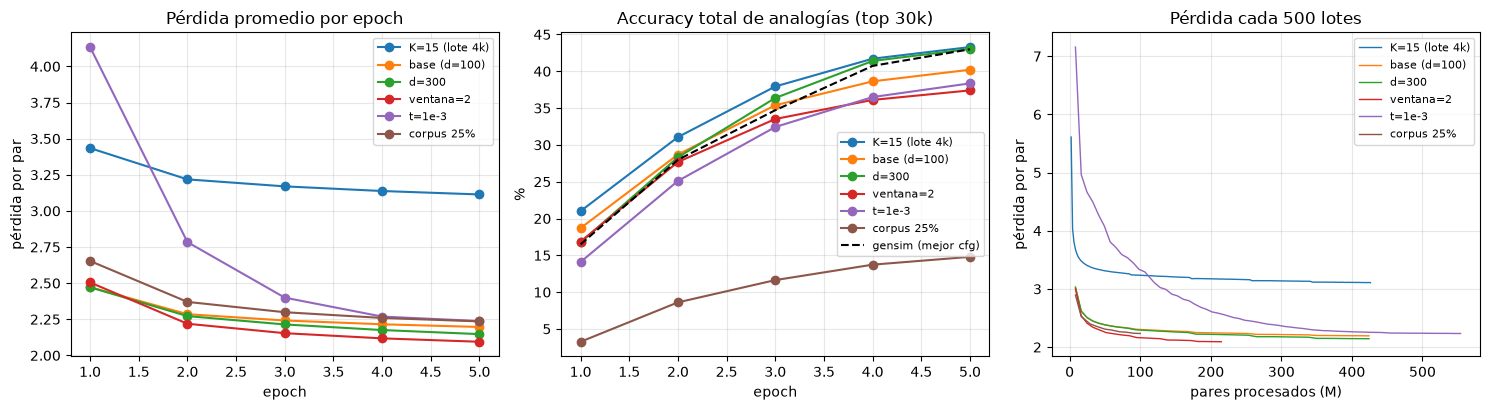

In [24]:
graficar = [MEJOR] + [n for n in ('base (d=100)', 'd=300', 'ventana=2', 'K=15 (lote 4k)', 't=1e-3', 'corpus 25%') if n != MEJOR]
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
for n in graficar:
    ep = RESULTADOS[n]['hist']['epochs']
    x = [e['epoch'] for e in ep]
    axs[0].plot(x, [e['perdida'] for e in ep], 'o-', label=n)
    axs[1].plot(x, [e['total'] for e in ep], 'o-', label=n)
    pasos = RESULTADOS[n]['hist']['perdida_pasos']
    axs[2].plot([p[0] / 1e6 for p in pasos], [p[1] for p in pasos], lw=1, label=n)
axs[1].plot([e['epoch'] for e in hist_gensim['epochs']], [e['total'] for e in hist_gensim['epochs']],
            'k--', label='gensim (mejor cfg)')
axs[0].set(title='Pérdida promedio por epoch', xlabel='epoch', ylabel='pérdida por par')
axs[1].set(title='Accuracy total de analogías (top 30k)', xlabel='epoch', ylabel='%')
axs[2].set(title='Pérdida cada 500 lotes', xlabel='pares procesados (M)', ylabel='pérdida por par')
for ax in axs: ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(os.path.join(REPORTS, 'curvas_sgns.png'), dpi=150); plt.show()

**¿Una pérdida más baja implica siempre mejores embeddings? No.**

- Entre configuraciones la pérdida **no es comparable**: `ventana=2` tiene la pérdida más baja (2.09) y es de las peores
  en analogías (37.4 %), porque predecir los vecinos inmediatos es una tarea más fácil. `K=15` tiene la pérdida más
  alta (3.11) simplemente porque suma 15 términos negativos en lugar de 5, y aun así es el mejor modelo.
- Dentro de una misma corrida, pérdida y calidad sí van juntas al principio, pero la pérdida sigue bajando cuando
  WordSim ya se estancó (base: ρ = 0.655 desde el epoch 3).
- La pérdida mide qué tan bien se resuelve la tarea **auxiliar** (distinguir contextos reales de negativos), no la
  calidad geométrica de los vectores; por eso se evalúa con benchmarks externos.

**SGNS propio vs. gensim** (misma configuración): 43.3 % vs 43.0 % en analogías y ρ = 0.654 vs 0.648 en WordSim, con
curvas de aprendizaje casi superpuestas → la implementación es correcta. La diferencia está en el **costo**: gensim
(C optimizado, 12 hilos de CPU, actualización par por par) tarda ~17 s por epoch; el SGNS en PyTorch sobre MPS ~115 s
con lotes de 4 k (~50 s con lotes de 16 k). Las pequeñas diferencias de accuracy vienen de la aleatoriedad
(submuestreo, negativos, hilos) y de que el SGNS actualiza en lotes en lugar de par por par.

**Vecinos de control:** `france` → `spain, italy, belgium, portugal`; `january` → otros meses; `computer` →
`computers, software, simulation`; `good` → `bad, decent, excellent` (antónimos cercanos: aparecen en los mismos
contextos, típico de embeddings distribucionales). `run` → `runs, baserunner, unearned` y `king` → `lionheart,
uncrowned, æthelflæd` reflejan el **dominio** de Wikipedia (béisbol, historia medieval).